In [147]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [148]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [149]:
image_ds = tf.data.Dataset.list_files("data/kitti/training/image_2/*.png", shuffle=False)
mask_ds = tf.data.Dataset.list_files("data/kitti/training/semantic/*.png", shuffle=False)
dataset = tf.data.Dataset.zip((image_ds, mask_ds))

In [150]:
for path in image_ds.take(5):
    print(path.numpy())

b'data/kitti/training/image_2/000000_10.png'
b'data/kitti/training/image_2/000001_10.png'
b'data/kitti/training/image_2/000002_10.png'
b'data/kitti/training/image_2/000003_10.png'
b'data/kitti/training/image_2/000004_10.png'


In [151]:
for path in mask_ds.take(5):
    print(path.numpy())

b'data/kitti/training/semantic/000000_10.png'
b'data/kitti/training/semantic/000001_10.png'
b'data/kitti/training/semantic/000002_10.png'
b'data/kitti/training/semantic/000003_10.png'
b'data/kitti/training/semantic/000004_10.png'


In [152]:
def load_preprocess(image_path, mask_path):
    image = tf.io.read_file(image_path)
    mask = tf.io.read_file(mask_path)

    image = tf.image.decode_png(image, channels=3)
    mask = tf.image.decode_png(mask, channels=1)

    resized_image = tf.image.resize(image, [512,512])
    resized_mask = tf.image.resize(mask, [512,512], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    resized_image = resized_image / 255.0

    return resized_image, resized_mask

In [153]:
dataset = dataset.map(load_preprocess)

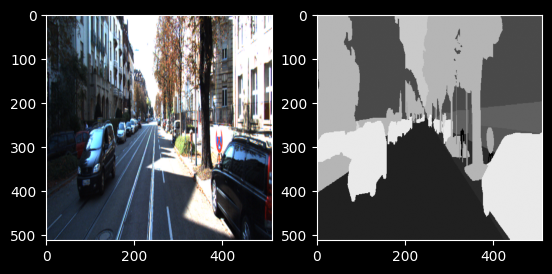

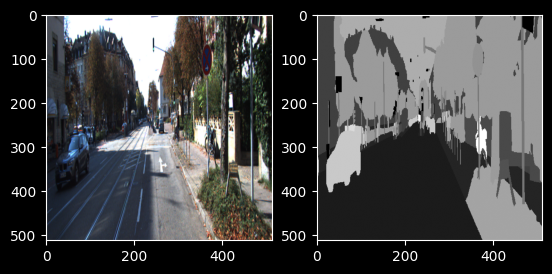

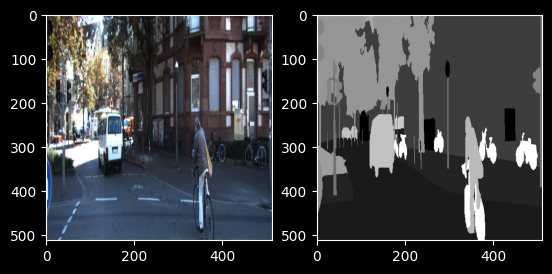

In [154]:
for feature, label in dataset.take(3):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.imshow(feature)
    ax2.imshow(tf.squeeze(label), cmap='gray')
    plt.show()

In [155]:
train_ds = dataset.take(160).shuffle(160).batch(4).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(160).batch(4).prefetch(tf.data.AUTOTUNE)

In [156]:
import importlib
import unet
importlib.reload(unet)
from unet import build_unet

In [157]:
model = build_unet((512, 512, 3), 19)
model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_105 (Conv2D) │ (None, 512, 512,  │      1,792 │ input_layer_14[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_106 (Conv2D) │ (None, 512, 512,  │     36,928 │ conv2d_105[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_45    │ (None, 256, 256,  │          0 │ conv2d_106[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_107 (Conv2D) │ (None, 256, 256,  │     73,856 │ max_pooling2d_45… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_108 (Conv2D) │ (None, 256, 256,  │    147,584 │ conv2d_107[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_46    │ (None, 128, 128,  │          0 │ conv2d_108[0][0]  │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_109 (Conv2D) │ (None, 128, 128,  │    295,168 │ max_pooling2d_46… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_110 (Conv2D) │ (None, 128, 128,  │    590,080 │ conv2d_109[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_47    │ (None, 64, 64,    │          0 │ conv2d_110[0][0]  │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_111 (Conv2D) │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_47… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_112 (Conv2D) │ (None, 64, 64,    │  2,359,808 │ conv2d_111[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_48    │ (None, 32, 32,    │          0 │ conv2d_112[0][0]  │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_113 (Conv2D) │ (None, 32, 32,    │  4,719,616 │ max_pooling2d_48… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_114 (Conv2D) │ (None, 32, 32,    │  9,438,208 │ conv2d_113[0][0]  │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_12 │ (None, 64, 64,    │  2,097,664 │ conv2d_114[0][0]  │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 64, 64,    │          0 │ conv2d_transpose

 Total params: 31,032,915 (118.38 MB)

 Trainable params: 31,032,915 (118.38 MB)

 Non-trainable params: 0 (0.00 B)